# Data Preparation: Jalur Irisan 3 Kelas (Versi MD5 + pHash)
### Standardisasi, Deduplikasi Berbasis Isi Gambar, dan Pemisahan Data Bebas Kebocoran Lesi

Ini versi lanjutan dari notebook `irisan_mapping_improve.ipynb`. Bagian yang beda cuma satu, tapi cukup penting: cara deteksi duplikatnya. Versi awal cuma ngecek dari nama file (`image_id`), jadi asumsinya "kalau ID sama, berarti gambarnya sama". Di versi ini kita cek langsung dari isi filenya:

1. Memindai citra fisik (.jpg) dari ketiga dataset sumber (HAM10000, ISIC 2019, dan ISIC 2017).
2. Membuang duplikat yang identik 100% (byte-per-byte sama) pakai **MD5 Hash**.
3. Membuang duplikat yang mirip tapi gak identik (beda kompresi/ukuran dikit) pakai **pHash + Hamming Distance**.
4. Menyeragamkan label diagnosis dan mengambil irisan 3 kelas bersama (NV, MEL, BKL).
5. Membagi data jadi Train (80%), Val (10%), Test (10%) berbasis `lesion_id` (Stratified Group K-Fold) biar gak ada kebocoran data pasien.

Catatan: notebook ini sudah disesuaikan supaya bisa langsung jalan di Kaggle (path dataset dicari otomatis, output disimpan ke `/kaggle/working`). Kalau ternyata folder dataset kamu gak kedeteksi otomatis, tinggal set manual variabel `ROOT` di Langkah 1.

## Langkah 1: Setup Library dan Path Dataset
Install & import library yang dipakai, terus cari lokasi folder dataset. Kode di bawah bakal coba beberapa lokasi umum dulu, kalau belum ketemu baru scan otomatis isi `/kaggle/input/`.

In [35]:
!pip install imagehash -q

In [36]:
import os
import glob
import hashlib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm
import imagehash
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 110
tqdm.pandas()

# Deteksi root dataset (Kaggle /kaggle/input vs Lokal)
def temukan_root_dataset():
    if os.path.exists('/kaggle/input'):
        for root, dirs, _ in os.walk('/kaggle/input'):
            if 'Dataset' in dirs:
                return os.path.join(root, 'Dataset')
            if any(k in [d.lower() for d in dirs] for k in ['ham10k', 'ham10000']):
                return root
        kaggle_items = [os.path.join('/kaggle/input', d) for d in os.listdir('/kaggle/input') if os.path.isdir(os.path.join('/kaggle/input', d))]
        if kaggle_items:
            return kaggle_items[0]

    local_candidates = [
        os.path.join(os.getcwd(), 'Dataset'),
        os.path.join(os.path.dirname(os.getcwd()), 'Dataset'),
        os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'Dataset'),
        r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset",
        os.getcwd()
    ]
    for cand in local_candidates:
        if cand and os.path.exists(cand):
            return cand
    return None

ROOT = temukan_root_dataset()
if ROOT is None:
    raise FileNotFoundError(
        "Folder Dataset gak ketemu sama sekali. Cek lagi nama/lokasi dataset yang kamu upload di Kaggle, "
        "terus set manual variabel ROOT di cell ini."
    )

# Direktori output (di Kaggle wajib /kaggle/working karena /kaggle/input bersifat read-only)
if os.path.exists('/kaggle/working'):
    OUTPUT_DIR = '/kaggle/working'
elif ROOT and os.path.exists(ROOT):
    OUTPUT_DIR = ROOT
else:
    OUTPUT_DIR = os.getcwd()

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper pencarian folder/file otomatis (case-insensitive, rekursif)
def cari_path(nama_target, is_dir=True):
    search_roots = []
    if os.path.exists('/kaggle/input'):
        search_roots.append('/kaggle/input')
    if ROOT and os.path.exists(ROOT):
        search_roots.append(ROOT)
    search_roots.extend([os.getcwd(), os.path.join(os.getcwd(), 'Dataset')])

    for base in search_roots:
        if not os.path.exists(base):
            continue
        for root, dirs, files in os.walk(base):
            items = dirs if is_dir else files
            for item in items:
                if item.lower() == nama_target.lower():
                    return os.path.join(root, item)
    return None

def resolve_dir(nama_target, fallback_rel):
    found = cari_path(nama_target, is_dir=True)
    if found:
        return found
    if ROOT:
        return os.path.join(ROOT, fallback_rel)
    return nama_target

def resolve_file(nama_target, fallback_rel):
    found = cari_path(nama_target, is_dir=False)
    if found:
        return found
    if not nama_target.endswith('.csv'):
        found_csv = cari_path(nama_target + '.csv', is_dir=False)
        if found_csv:
            return found_csv
    if ROOT:
        return os.path.join(ROOT, fallback_rel)
    return nama_target

SOURCES = {
    'ham10000': {
        'nama': 'HAM10000 (ViDIR Austria & Queensland Australia)',
        'img_dirs': [
            resolve_dir('HAM10000_images_part_1', os.path.join('HAM10K', 'HAM10000_images_part_1')),
            resolve_dir('HAM10000_images_part_2', os.path.join('HAM10K', 'HAM10000_images_part_2')),
        ],
        'gt_path': resolve_file('HAM10000_metadata', os.path.join('HAM10K', 'HAM10000_metadata')),
        'fmt': 'ham_dx'
    },
    'isic_2019_train': {
        'nama': 'ISIC 2019 Training Input (BCN-20000 + ViDIR + HAM10k Overlap)',
        'img_dir': resolve_dir('ISIC_2019_Training_Input', os.path.join('isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')),
        'gt_path': resolve_file('ISIC_2019_Training_GroundTruth.csv', os.path.join('isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv')),
        'fmt': 'onehot9'
    },
    'isic_2017_train': {
        'nama': 'ISIC 2017 Training Data',
        'img_dir': resolve_dir('ISIC-2017_Training_Data', os.path.join('isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data')),
        'gt_path': resolve_file('ISIC-2017_Training_Part3_GroundTruth.csv', os.path.join('isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv')),
        'fmt': '2017'
    },
    'isic_2017_val': {
        'nama': 'ISIC 2017 Validation Data',
        'img_dir': resolve_dir('ISIC-2017_Validation_Data', os.path.join('isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data')),
        'gt_path': resolve_file('ISIC-2017_Validation_Part3_GroundTruth.csv', os.path.join('isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv')),
        'fmt': '2017'
    },
    'isic_2017_test': {
        'nama': 'ISIC 2017 Test Data (v2)',
        'img_dir': resolve_dir('ISIC-2017_Test_v2_Data', os.path.join('isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data')),
        'gt_path': resolve_file('ISIC-2017_Test_v2_Part3_GroundTruth.csv', os.path.join('isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv')),
        'fmt': '2017'
    }
}

print(f"Folder Dataset input terdeteksi : {ROOT}")
print(f"Folder Output penyimpanan       : {OUTPUT_DIR}")
print("\nDaftar 5 partisi sumber data yang dikonfigurasi:")
for k, v in SOURCES.items():
    print(f"- {k}: {v['nama']}")

Folder Dataset input terdeteksi : /kaggle/input/datasets/nadiraanindita/dataset-riset-ham10k
Folder Output penyimpanan       : /kaggle/working

Daftar 5 partisi sumber data yang dikonfigurasi:
- ham10000: HAM10000 (ViDIR Austria & Queensland Australia)
- isic_2019_train: ISIC 2019 Training Input (BCN-20000 + ViDIR + HAM10k Overlap)
- isic_2017_train: ISIC 2017 Training Data
- isic_2017_val: ISIC 2017 Validation Data
- isic_2017_test: ISIC 2017 Test Data (v2)


## Langkah 2: Pemindaian File Gambar dan Ground Truth
Cek semua file citra (.jpg) yang ada di disk, terus pasangkan sama label diagnosis aslinya dari file CSV masing-masing dataset. Bagian ini sama persis kayak versi sebelumnya, belum ada yang diubah.

In [37]:
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        # khusus ham10000, gambarnya kepisah jadi 2 folder
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)

gt_records = {}

# HAM10000
df_ham = pd.read_csv(SOURCES['ham10000']['gt_path'])
gt_records['ham10000'] = dict(zip(df_ham['image_id'], df_ham['dx'].str.lower()))

# ISIC 2019 (formatnya one-hot, jadi harus dicari kolom mana yang nilainya 1)
df_19 = pd.read_csv(SOURCES['isic_2019_train']['gt_path'])
cols_19 = [c for c in df_19.columns if c not in ('image', 'score_weight', 'validation_weight')]
gt_19 = {}
for _, r in df_19.iterrows():
    for c in cols_19:
        if r[c] == 1.0:
            gt_19[r['image']] = c
            break
gt_records['isic_2019_train'] = gt_19

for s in ['isic_2017_train', 'isic_2017_val', 'isic_2017_test']:
    df_17 = pd.read_csv(SOURCES[s]['gt_path'])
    id_col = 'image_id' if 'image_id' in df_17.columns else df_17.columns[0]
    gt_17 = {}
    for _, r in df_17.iterrows():
        img_id = str(r[id_col]).replace('.jpg', '')
        if r.get('melanoma') == 1.0:
            gt_17[img_id] = 'melanoma'
        elif r.get('seborrheic_keratosis') == 1.0:
            gt_17[img_id] = 'seborrheic_keratosis'
        else:
            gt_17[img_id] = 'nevus'
    gt_records[s] = gt_17

df_images['original_label'] = df_images.apply(
    lambda r: gt_records.get(r['source'], {}).get(r['image_id'], np.nan), axis=1
)

print(f"Total citra fisik terindeks dari seluruh sumber: {len(df_images):,} citra")
for src in SOURCES.keys():
    sub = df_images[df_images['source'] == src]
    print(f"- {src}: {len(sub):,} citra fisik ({sub['original_label'].notna().sum():,} memiliki label)")

Total citra fisik terindeks dari seluruh sumber: 38,096 citra
- ham10000: 10,015 citra fisik (10,015 memiliki label)
- isic_2019_train: 25,331 citra fisik (25,331 memiliki label)
- isic_2017_train: 2,000 citra fisik (2,000 memiliki label)
- isic_2017_val: 150 citra fisik (150 memiliki label)
- isic_2017_test: 600 citra fisik (600 memiliki label)


## Langkah 3: Deteksi Duplikat Persis (MD5 Hash)
Deduplikasi versi awal cuma ngecek nama file, padahal itu cuma asumsi. Di sini kita cek beneran isi filenya lewat MD5 hash - kalau dua file MD5-nya sama, dijamin isinya identik 100% sampai ke level byte.

Urutan prioritas kalau ketemu duplikat masih sama kayak sebelumnya: HAM10000 dipertahankan penuh dulu, baru ISIC 2019, lalu ISIC 2017 (train, val, test).

In [38]:
def hitung_md5(filepath):
    # dihash dari bytes mentah file-nya, bukan dari pixel gambar
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("Hitung MD5 tiap citra dulu, agak lama soalnya harus buka file satu-satu...")
df_images['md5_hash'] = df_images['filepath'].progress_apply(hitung_md5)
print("Selesai.")

PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]
priority_rank = {src: i for i, src in enumerate(PRIORITY_ORDER)}

df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_rank)

df_sorted_md5 = df_all.sort_values(by=['md5_hash', 'priority'])
df_after_md5 = df_sorted_md5.drop_duplicates(subset='md5_hash', keep='first').copy()
df_dropped_md5 = df_sorted_md5[~df_sorted_md5.index.isin(df_after_md5.index)].copy()

kept_map_md5 = df_after_md5.set_index('md5_hash')['source'].to_dict()
df_dropped_md5['kept_in_source'] = df_dropped_md5['md5_hash'].map(kept_map_md5)

before_counts = df_all['source'].value_counts()
after_counts_md5 = df_after_md5['source'].value_counts()
dropped_counts_md5 = df_dropped_md5['source'].value_counts()

rows_md5 = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts_md5.get(src, 0)
    d = dropped_counts_md5.get(src, 0)

    dropped_src = df_dropped_md5[df_dropped_md5['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,})" for k, v in kept_counts.items()])
    else:
        detail_kept = "- (Data primer utuh)"

    rows_md5.append({
        'Source Dataset': src,
        'Before (Awal)': f"{b:,}",
        'Duplikat MD5 Dihapus': f"{d:,}",
        'Duplikat dengan Dataset Mana': detail_kept,
        'After (Sisa Unik)': f"{a:,}",
        'Persentase Bertahan': f"{a/b*100:.1f}%"
    })

df_md5_table = pd.DataFrame(rows_md5)
display(df_md5_table)

print(f"\nTotal citra awal                  : {len(df_all):,} citra")
print(f"Duplikat persis (MD5) yang dibuang : {len(df_dropped_md5):,} citra")
print(f"Sisa citra unik setelah MD5        : {len(df_after_md5):,} citra")

Hitung MD5 tiap citra dulu, agak lama soalnya harus buka file satu-satu...


  0%|          | 0/38096 [00:00<?, ?it/s]

Selesai.


,Source Dataset,Before (Awal),Duplikat MD5 Dihapus,Duplikat dengan Dataset Mana,After (Sisa Unik),Persentase Bertahan
0,ham10000,"10,015",2,ham10000 (2),"10,013",100.0%
1,isic_2019_train,"25,331","10,063","ham10000 (10,015); isic_2019_train (48)","15,268",60.3%
2,isic_2017_train,"2,000",717,isic_2019_train (717),"1,283",64.1%
3,isic_2017_val,150,3,isic_2019_train (2); isic_2017_train (1),147,98.0%
4,isic_2017_test,600,6,isic_2017_train (2); isic_2017_test (2); isic_...,594,99.0%



Total citra awal                  : 38,096 citra
Duplikat persis (MD5) yang dibuang : 10,791 citra
Sisa citra unik setelah MD5        : 27,305 citra


## Langkah 4: Deteksi Near-Duplicate (pHash + Hamming Distance)
MD5 cuma nangkep duplikat yang identik banget. Padahal ada kemungkinan gambar yang sama tapi ukuran/kompresinya beda dikit (misal satu diresize, satu lagi hasil crop tipis) - file-nya jadi beda secara byte walau isinya kelihatan sama di mata. Untuk kasus kayak gini kita pakai **perceptual hash (pHash)**: tiap gambar diringkas jadi "sidik jari visual" 64-bit, lalu dua sidik jari itu dibandingin pakai **Hamming Distance** (jumlah bit yang beda). Makin kecil jaraknya, makin mirip dua gambarnya.

Threshold yang dipakai `HAMMING_THRESHOLD = 5` (dari 64 bit total) - nilai yang cukup umum buat nangkep gambar yang "hampir pasti sama". Tapi tetap disarankan cek manual beberapa pasangan yang kedeteksi (ada di cell setelah ini), soalnya dua lesi kulit dari orang berbeda kadang emang kelihatan mirip dan gak boleh ikut kebuang.

In [39]:
def hitung_phash(filepath):
    try:
        with Image.open(filepath) as img:
            return imagehash.phash(img)
    except Exception:
        return None

print("Hitung pHash untuk sisa citra yang lolos tahap MD5...")
df_after_md5['phash'] = df_after_md5['filepath'].progress_apply(hitung_phash)

gagal_buka = df_after_md5['phash'].isna().sum()
if gagal_buka > 0:
    print(f"Ada {gagal_buka} citra gagal dibuka (kemungkinan corrupt), bakal di-skip dari pengecekan ini.")
df_valid = df_after_md5[df_after_md5['phash'].notna()].reset_index(drop=True)

print("Selesai hitung pHash. Sekarang nyari pasangan yang mirip...")

# ubah tiap hash jadi array bit 0/1 (panjangnya 64 karena default hash_size pHash = 8x8)
hash_bits = np.stack([h.hash.flatten() for h in df_valid['phash']]).astype(np.float32)
popcount = hash_bits.sum(axis=1)  # jumlah bit 1 di tiap hash

N = len(hash_bits)
HAMMING_THRESHOLD = 5
CHUNK_SIZE = 2000  # diproses per-chunk biar RAM gak jebol pas N-nya gede

pasangan_mirip = []
idx_range = np.arange(N)  # dibuat sekali aja di luar loop, biar gak bikin array baru tiap iterasi

for start in tqdm(range(0, N, CHUNK_SIZE)):
    end = min(start + CHUNK_SIZE, N)
    chunk = hash_bits[start:end]

    # rumus: hamming_distance(a, b) = popcount(a) + popcount(b) - 2 * dot(a, b)
    # jadi gak perlu loop bit satu-satu, cukup matrix multiply (lebih cepat)
    dot = chunk @ hash_bits.T
    jarak = popcount[start:end, None] + popcount[None, :] - 2 * dot

    for i in range(chunk.shape[0]):
        idx_global = start + i
        # cuma ambil index yang lebih besar biar gak dobel kehitung & gak bandingin ke diri sendiri
        kandidat = np.where((jarak[i] <= HAMMING_THRESHOLD) & (idx_range > idx_global))[0]
        for j in kandidat:
            pasangan_mirip.append((idx_global, int(j)))

print(f"Ketemu {len(pasangan_mirip):,} pasangan citra yang mirip (Hamming Distance <= {HAMMING_THRESHOLD}).")

Hitung pHash untuk sisa citra yang lolos tahap MD5...


  0%|          | 0/27305 [00:00<?, ?it/s]

Selesai hitung pHash. Sekarang nyari pasangan yang mirip...


  0%|          | 0/14 [00:00<?, ?it/s]

Ketemu 4,032 pasangan citra yang mirip (Hamming Distance <= 5).


In [40]:
# kelompokin pasangan yang mirip jadi cluster pakai union-find sederhana
# (kalau A mirip B, B mirip C, maka A-B-C dianggap satu cluster meski A-C sendiri gak dibandingin langsung)
parent = list(range(N))

def cari_root(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def gabung(x, y):
    rx, ry = cari_root(x), cari_root(y)
    if rx != ry:
        parent[rx] = ry

for i, j in pasangan_mirip:
    gabung(i, j)

df_valid['cluster_id'] = [cari_root(i) for i in range(N)]
df_valid['priority'] = df_valid['source'].map(priority_rank)

# tiap cluster cuma boleh nyisain 1 citra, prioritasnya sama kayak tahap MD5
df_valid_sorted = df_valid.sort_values(by=['cluster_id', 'priority'])
df_clean = df_valid_sorted.drop_duplicates(subset='cluster_id', keep='first').copy()
df_dropped_phash = df_valid_sorted[~df_valid_sorted.index.isin(df_clean.index)].copy()

kept_map_phash = df_clean.set_index('cluster_id')['source'].to_dict()
df_dropped_phash['kept_in_source'] = df_dropped_phash['cluster_id'].map(kept_map_phash)

after_counts_phash = df_clean['source'].value_counts()
dropped_counts_phash = df_dropped_phash['source'].value_counts()

rows_phash = []
for src in PRIORITY_ORDER:
    b = after_counts_md5.get(src, 0)  # jumlah sebelum tahap pHash (sisa dari tahap MD5)
    a = after_counts_phash.get(src, 0)
    d = dropped_counts_phash.get(src, 0)

    dropped_src = df_dropped_phash[df_dropped_phash['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,})" for k, v in kept_counts.items()])
    else:
        detail_kept = "- (Tidak ada near-duplicate)"

    rows_phash.append({
        'Source Dataset': src,
        'Sebelum pHash': f"{b:,}",
        'Near-Duplicate Dihapus': f"{d:,}",
        'Mirip dengan Dataset Mana': detail_kept,
        'Sisa Akhir': f"{a:,}",
    })

df_phash_table = pd.DataFrame(rows_phash)
display(df_phash_table)

df_clean = df_clean.reset_index(drop=True)

print(f"\nTotal citra sebelum pHash          : {len(df_after_md5):,} citra")
print(f"Near-duplicate yang dibuang         : {len(df_dropped_phash):,} citra")
print(f"Total citra unik bersih akhir       : {len(df_clean):,} citra")
print(f"\nRingkasan gabungan (MD5 + pHash):")
print(f"Total citra awal                    : {len(df_all):,} citra")
print(f"Total duplikat dibuang (MD5 + pHash): {len(df_all) - len(df_clean):,} citra")
print(f"Total citra unik bersih final        : {len(df_clean):,} citra")

,Source Dataset,Sebelum pHash,Near-Duplicate Dihapus,Mirip dengan Dataset Mana,Sisa Akhir
0,ham10000,"10,013",306,ham10000 (306),"9,707"
1,isic_2019_train,"15,268",908,isic_2019_train (780); ham10000 (128),"14,360"
2,isic_2017_train,"1,283","1,283","isic_2019_train (1,263); ham10000 (20)",0
3,isic_2017_val,147,147,isic_2019_train (143); ham10000 (4),0
4,isic_2017_test,594,594,isic_2019_train (580); ham10000 (14),0



Total citra sebelum pHash          : 27,305 citra
Near-duplicate yang dibuang         : 3,238 citra
Total citra unik bersih akhir       : 24,067 citra

Ringkasan gabungan (MD5 + pHash):
Total citra awal                    : 38,096 citra
Total duplikat dibuang (MD5 + pHash): 14,029 citra
Total citra unik bersih final        : 24,067 citra


### Cek Manual Beberapa Pasangan Near-Duplicate
Sebelum lanjut, mending liat langsung beberapa contoh pasangan yang kedeteksi mirip. Tujuannya buat mastiin `HAMMING_THRESHOLD` yang dipakai udah pas, bukan kelewat longgar sampai nganggep dua lesi dari orang berbeda jadi "sama".

In [ ]:
contoh_cluster = df_dropped_phash['cluster_id'].value_counts().index[:3] if len(df_dropped_phash) > 0 else []

if len(contoh_cluster) > 0:
    for cid in contoh_cluster:
        anggota = df_valid[df_valid['cluster_id'] == cid]
        fig, axes = plt.subplots(1, len(anggota), figsize=(4 * len(anggota), 4))
        if len(anggota) == 1:
            axes = [axes]
        for ax, (_, row) in zip(axes, anggota.iterrows()):
            try:
                img = Image.open(row['filepath'])
                ax.imshow(img)
                ax.set_title(f"{row['source']}\n{row['image_id']}", fontsize=9)
            except Exception:
                pass
            ax.axis('off')
        plt.suptitle(f"Cluster near-duplicate #{cid}")
        plt.tight_layout()
        plt.show()
else:
    print("Gak ada near-duplicate yang kedeteksi, jadi gak ada yang perlu dicek manual.")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

## Langkah 5: Harmonisasi Label Diagnosis Medis
Menyeragamkan variasi istilah diagnosis dari masing-masing dataset menjadi kode standar medis internasional (seborrheic_keratosis dilebur ke BKL sesuai ontologi medis). Bagian ini logikanya sama kayak versi sebelumnya, cuma sekarang jalan di atas `df_clean` hasil dedup MD5 + pHash.

In [49]:
HARMONIZATION_MAP = {
    'nv': 'NV', 'mel': 'MEL', 'bkl': 'BKL', 'bcc': 'BCC',
    'akiec': 'AKIEC', 'vasc': 'VASC', 'df': 'DF',
    'nevus': 'NV', 'melanoma': 'MEL', 'seborrheic_keratosis': 'BKL',
    'NV': 'NV', 'MEL': 'MEL', 'BKL': 'BKL', 'BCC': 'BCC',
    'AK': 'AKIEC', 'SCC': 'SCC', 'VASC': 'VASC', 'DF': 'DF'
}

MED_DESC = {
    'NV': ('Melanocytic Nevus', 'Tahi lalat jinak melanositik'),
    'MEL': ('Melanoma', 'Kanker kulit ganas melanosit'),
    'BKL': ('Benign Keratosis', 'Keratosis seboroik / lentigo surya jinak'),
    'BCC': ('Basal Cell Carcinoma', 'Karsinoma sel basal ganas'),
    'AKIEC': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik'),
    'VASC': ('Vascular Lesion', 'Kelainan pembuluh darah kulit jinak'),
    'DF': ('Dermatofibroma', 'Nodul jinak jaringan ikat fibrohistiositik'),
    'SCC': ('Squamous Cell Carcinoma', 'Karsinoma sel skuamosa ganas')
}

df_clean['harmonized_label'] = df_clean['original_label'].map(HARMONIZATION_MAP)

harm_summary = []
for code_, (med_name, desc) in MED_DESC.items():
    cnt_ham = len(df_clean[(df_clean['source'] == 'ham10000') & (df_clean['harmonized_label'] == code_)])
    cnt_19 = len(df_clean[(df_clean['source'] == 'isic_2019_train') & (df_clean['harmonized_label'] == code_)])
    cnt_17 = len(df_clean[(df_clean['source'].str.contains('isic_2017')) & (df_clean['harmonized_label'] == code_)])
    tot = cnt_ham + cnt_19 + cnt_17

    status_irisan = "Ada di ketiga dataset (Irisan)" if (cnt_ham > 0 and cnt_19 > 0 and cnt_17 > 0) else "Gugur (Tidak ada di ISIC 2017)"
    harm_summary.append({
        'Kode': code_,
        'Nama Diagnosis Medis': med_name,
        'Deskripsi Patologis': desc,
        'HAM10000': f"{cnt_ham:,}",
        'ISIC 2019 (Unik)': f"{cnt_19:,}",
        'ISIC 2017 (Unik)': f"{cnt_17:,}",
        'Total Bersih': f"{tot:,}",
        'Status Irisan 3 Dataset': status_irisan
    })

df_harm_table = pd.DataFrame(harm_summary)
display(df_harm_table)

,Kode,Nama Diagnosis Medis,Deskripsi Patologis,HAM10000,ISIC 2019 (Unik),ISIC 2017 (Unik),Total Bersih,Status Irisan 3 Dataset
0,NV,Melanocytic Nevus,Tahi lalat jinak melanositik,"6,440","5,820",0,"12,260",Gugur (Tidak ada di ISIC 2017)
1,MEL,Melanoma,Kanker kulit ganas melanosit,"1,089","3,255",0,"4,344",Gugur (Tidak ada di ISIC 2017)
2,BKL,Benign Keratosis,Keratosis seboroik / lentigo surya jinak,"1,091","1,438",0,"2,529",Gugur (Tidak ada di ISIC 2017)
3,BCC,Basal Cell Carcinoma,Karsinoma sel basal ganas,512,"2,566",0,"3,078",Gugur (Tidak ada di ISIC 2017)
4,AKIEC,Actinic Keratosis,Lesi pra-kanker keratinositik,324,664,0,988,Gugur (Tidak ada di ISIC 2017)
5,VASC,Vascular Lesion,Kelainan pembuluh darah kulit jinak,138,102,0,240,Gugur (Tidak ada di ISIC 2017)
6,DF,Dermatofibroma,Nodul jinak jaringan ikat fibrohistiositik,113,114,0,227,Gugur (Tidak ada di ISIC 2017)
7,SCC,Squamous Cell Carcinoma,Karsinoma sel skuamosa ganas,0,401,0,401,Gugur (Tidak ada di ISIC 2017)


## Langkah 6: Penentuan Irisan Bersama Antar-Dataset
Mengevaluasi irisan himpunan label yang dimiliki bersama oleh HAM10000, ISIC 2019, dan ISIC 2017.

In [50]:
harmonized_pre_dedup = df_images['original_label'].map(HARMONIZATION_MAP)

classes_ham = set(harmonized_pre_dedup[df_images['source'] == 'ham10000'].dropna().unique())
classes_19 = set(harmonized_pre_dedup[df_images['source'] == 'isic_2019_train'].dropna().unique())
classes_17 = set(harmonized_pre_dedup[df_images['source'].str.contains('isic_2017')].dropna().unique())

irisan_3kelas = sorted(list(classes_ham.intersection(classes_19).intersection(classes_17)))
dropped_classes = sorted(list((classes_ham | classes_19) - set(irisan_3kelas)))

print(f"Kelas pada HAM10000  ({len(classes_ham)} kelas) : {sorted(list(classes_ham))}")
print(f"Kelas pada ISIC 2019 ({len(classes_19)} kelas) : {sorted(list(classes_19))}")
print(f"Kelas pada ISIC 2017 ({len(classes_17)} kelas) : {sorted(list(classes_17))}")
print(f"Hasil Irisan Bersama ({len(irisan_3kelas)} kelas) : {irisan_3kelas}")
print(f"Kelas yang Gugur     ({len(dropped_classes)} kelas) : {dropped_classes}")

Kelas pada HAM10000  (7 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Kelas pada ISIC 2019 (8 kelas) : ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Kelas pada ISIC 2017 (3 kelas) : ['BKL', 'MEL', 'NV']
Hasil Irisan Bersama (3 kelas) : ['BKL', 'MEL', 'NV']
Kelas yang Gugur     (5 kelas) : ['AKIEC', 'BCC', 'DF', 'SCC', 'VASC']


## Langkah 7: Penyaringan 3 Kelas dan Validasi Integritas Data
Menyaring data unik pada 3 kelas terpilih, memetakan label diagnosis ke integer target (NV=0, MEL=1, BKL=2), dan memvalidasi kelengkapan data.

Catatan: total citra final di sini kemungkinan besar **beda** dari versi ID-matching (yang dulu pas tepat 22.051), karena metode deteksi duplikatnya beda total - sekarang berbasis isi gambar (MD5 + pHash), bukan cuma cocokin nama file. Jadi di sini gak dipasang assert angka mati, cuma dicek gak ada missing value aja.

In [51]:
df_3kelas_final = df_clean[df_clean['harmonized_label'].isin(irisan_3kelas)].copy().reset_index(drop=True)

CLASS_MAP_3 = {
    'NV': (0, 'Melanocytic Nevus (Tahi Lalat Jinak)'),
    'MEL': (1, 'Melanoma (Kanker Ganas)'),
    'BKL': (2, 'Benign Keratosis (Keratosis Seboroik Jinak)')
}

df_3kelas_final['target_multiclass'] = df_3kelas_final['harmonized_label'].map(lambda x: CLASS_MAP_3[x][0])
df_3kelas_final['class_name'] = df_3kelas_final['harmonized_label'].map(lambda x: CLASS_MAP_3[x][1])

total_awal_unik = len(df_clean)
total_akhir_3k  = len(df_3kelas_final)
total_gugur     = total_awal_unik - total_akhir_3k

print(f"Total citra unik bersih gabungan : {total_awal_unik:,} citra")
print(f"Citra gugur (di luar 3 kelas)    : {total_gugur:,} citra ({', '.join(dropped_classes)})")
print(f"Total citra final 3 kelas        : {total_akhir_3k:,} citra")
print(f"Missing Values pada target       : {df_3kelas_final['target_multiclass'].isna().sum()} baris")

assert df_3kelas_final['target_multiclass'].isna().sum() == 0, "Ada label yang gagal ke-mapping, cek lagi HARMONIZATION_MAP"
print("Validasi integritas sukses, tidak ada missing value di kolom target.")

print("\nContoh 10 baris pertama data final:")
display(df_3kelas_final[['image_id', 'source', 'original_label', 'harmonized_label', 'target_multiclass', 'class_name']].head(10))

Total citra unik bersih gabungan : 24,067 citra
Citra gugur (di luar 3 kelas)    : 4,934 citra (AKIEC, BCC, DF, SCC, VASC)
Total citra final 3 kelas        : 19,133 citra
Missing Values pada target       : 0 baris
Validasi integritas sukses, tidak ada missing value di kolom target.

Contoh 10 baris pertama data final:


,image_id,source,original_label,harmonized_label,target_multiclass,class_name
0,ISIC_0061409,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
1,ISIC_0029242,ham10000,mel,MEL,1,Melanoma (Kanker Ganas)
2,ISIC_0066295,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
3,ISIC_0031414,ham10000,nv,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
4,ISIC_0000287,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas)
5,ISIC_0000328,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
6,ISIC_0056543,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
7,ISIC_0070978,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)
8,ISIC_0059192,isic_2019_train,BKL,BKL,2,Benign Keratosis (Keratosis Seboroik Jinak)
9,ISIC_0025059,ham10000,nv,NV,0,Melanocytic Nevus (Tahi Lalat Jinak)


## Langkah 8: Visualisasi Distribusi 3 Kelas Hasil Irisan
Menampilkan tabel rekapitulasi data dan 2 grafik batang: sebaran total 3 kelas gabungan serta perbandingan kontribusi per sumber dataset.

,Source Dataset,Total Citra,NV (Nevus),MEL (Melanoma),BKL (Keratosis)
0,ham10000,"8,620","6,440 (74.7%)","1,089 (12.6%)","1,091 (12.7%)"
1,isic_2019_train,"10,513","5,820 (55.4%)","3,255 (31.0%)","1,438 (13.7%)"
2,TOTAL KESELURUHAN,"19,133","12,260 (64.1%)","4,344 (22.7%)","2,529 (13.2%)"


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

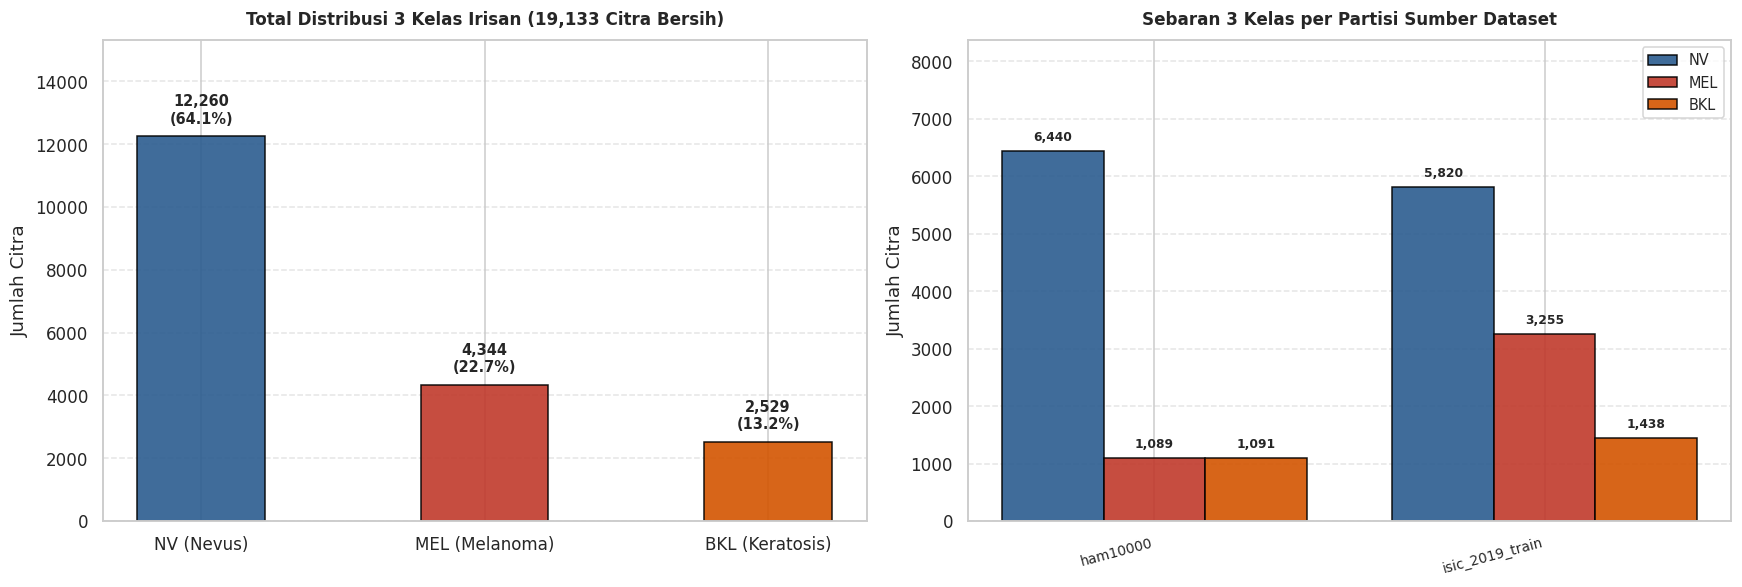

In [52]:
rekap_rows = []
sources_order = ['ham10000', 'isic_2019_train', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']

for src in sources_order:
    sub = df_3kelas_final[df_3kelas_final['source'] == src]
    tot = len(sub)
    if tot == 0:
        continue
    n_nv = len(sub[sub['harmonized_label'] == 'NV'])
    n_mel = len(sub[sub['harmonized_label'] == 'MEL'])
    n_bkl = len(sub[sub['harmonized_label'] == 'BKL'])

    rekap_rows.append({
        'Source Dataset': src,
        'Total Citra': f"{tot:,}",
        'NV (Nevus)': f"{n_nv:,} ({n_nv/tot*100:.1f}%)",
        'MEL (Melanoma)': f"{n_mel:,} ({n_mel/tot*100:.1f}%)",
        'BKL (Keratosis)': f"{n_bkl:,} ({n_bkl/tot*100:.1f}%)"
    })

tot_nv = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'NV'])
tot_mel = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'MEL'])
tot_bkl = len(df_3kelas_final[df_3kelas_final['harmonized_label'] == 'BKL'])

rekap_rows.append({
    'Source Dataset': 'TOTAL KESELURUHAN',
    'Total Citra': f"{total_akhir_3k:,}",
    'NV (Nevus)': f"{tot_nv:,} ({tot_nv/total_akhir_3k*100:.1f}%)",
    'MEL (Melanoma)': f"{tot_mel:,} ({tot_mel/total_akhir_3k*100:.1f}%)",
    'BKL (Keratosis)': f"{tot_bkl:,} ({tot_bkl/total_akhir_3k*100:.1f}%)"
})

df_rekap_3k = pd.DataFrame(rekap_rows)
display(df_rekap_3k)

# Visualisasi 2 Subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Total Distribusi
ax1 = axes[0]
classes_names = ['NV (Nevus)', 'MEL (Melanoma)', 'BKL (Keratosis)']
counts_classes = [tot_nv, tot_mel, tot_bkl]
colors_tri = ['#2b5c8f', '#c0392b', '#d35400']

bars1 = ax1.bar(classes_names, counts_classes, color=colors_tri, edgecolor='black', width=0.45, alpha=0.9)
ax1.set_title(f"Total Distribusi 3 Kelas Irisan ({total_akhir_3k:,} Citra Bersih)", fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel("Jumlah Citra")
ax1.set_ylim(0, max(counts_classes) * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    h = bar.get_height()
    pct = h / total_akhir_3k * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        h + (max(counts_classes) * 0.025),
        f"{int(h):,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=9.5, fontweight='bold'
    )

# 2. Perbandingan per Sumber Dataset
ax2 = axes[1]
datasets_list = [r['Source Dataset'] for r in rekap_rows if r['Source Dataset'] != 'TOTAL KESELURUHAN']
x = np.arange(len(datasets_list))
width = 0.26

nv_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'NV')]) for s in datasets_list]
mel_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'MEL')]) for s in datasets_list]
bkl_vals = [len(df_3kelas_final[(df_3kelas_final['source'] == s) & (df_3kelas_final['harmonized_label'] == 'BKL')]) for s in datasets_list]

rects_nv = ax2.bar(x - width, nv_vals, width=width, label='NV', color='#2b5c8f', edgecolor='black', alpha=0.9)
rects_mel = ax2.bar(x, mel_vals, width=width, label='MEL', color='#c0392b', edgecolor='black', alpha=0.9)
rects_bkl = ax2.bar(x + width, bkl_vals, width=width, label='BKL', color='#d35400', edgecolor='black', alpha=0.9)

max_val = max(max(nv_vals), max(mel_vals), max(bkl_vals))
ax2.set_ylim(0, max_val * 1.30)
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_list, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel("Jumlah Citra")
ax2.set_title("Sebaran 3 Kelas per Partisi Sumber Dataset", fontsize=11, fontweight='bold', pad=10)
ax2.legend(fontsize=9.5)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_nv:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

for rect in rects_mel:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

for rect in rects_bkl:
    h = rect.get_height()
    if h > 0:
        ax2.text(rect.get_x() + rect.get_width()/2.0, h + (max_val * 0.02), f"{int(h):,}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## Langkah 9: Ekspor Master Dataset Bersih
Menyimpan seluruh data bersih hasil irisan 3 kelas ke file CSV master. Disimpan ke `OUTPUT_DIR` (bukan `ROOT`), soalnya folder input Kaggle sifatnya read-only.

In [53]:
output_irisan_csv = os.path.join(OUTPUT_DIR, 'dataset_irisan_multiclass_hashdedup.csv')
cols_final = [
    'image_id',
    'source',
    'original_label',
    'harmonized_label',
    'target_multiclass',
    'class_name',
    'filepath'
]

df_3kelas_final[cols_final].to_csv(output_irisan_csv, index=False)

print(f"File master berhasil disimpan: {output_irisan_csv}")
print(f"Ukuran file: {os.path.getsize(output_irisan_csv) / (1024*1024):.2f} MB")
print(f"Total baris: {len(df_3kelas_final):,} citra")
print(f"Daftar kelas: 0=NV, 1=MEL, 2=BKL")

print("\nContoh 5 baris pertama file yang diekspor:")
display(pd.read_csv(output_irisan_csv).head(5))

File master berhasil disimpan: /kaggle/working/dataset_irisan_multiclass_hashdedup.csv
Ukuran file: 3.58 MB
Total baris: 19,133 citra
Daftar kelas: 0=NV, 1=MEL, 2=BKL

Contoh 5 baris pertama file yang diekspor:


,image_id,source,original_label,harmonized_label,target_multiclass,class_name,filepath
0,ISIC_0061409,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),/kaggle/input/datasets/nadiraanindita/dataset-...
1,ISIC_0029242,ham10000,mel,MEL,1,Melanoma (Kanker Ganas),/kaggle/input/datasets/nadiraanindita/dataset-...
2,ISIC_0066295,isic_2019_train,NV,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),/kaggle/input/datasets/nadiraanindita/dataset-...
3,ISIC_0031414,ham10000,nv,NV,0,Melanocytic Nevus (Tahi Lalat Jinak),/kaggle/input/datasets/nadiraanindita/dataset-...
4,ISIC_0000287,isic_2019_train,MEL,MEL,1,Melanoma (Kanker Ganas),/kaggle/input/datasets/nadiraanindita/dataset-...


## Langkah 10: Pembagian Data Bebas Kebocoran (Lesion-Aware Split 80:10:10)
Memetakan `lesion_id` pasien dan membagi data dengan StratifiedGroupKFold, biar seluruh citra dari lesi yang sama selalu ada di split yang sama (overlap lesi harus tepat 0).

In [54]:
# 1. Pemetaan lesion_id (HAM10000 + ISIC 2019)
ham_meta = pd.read_csv(SOURCES['ham10000']['gt_path'])[['image_id', 'lesion_id']]
isic19_meta_path = resolve_file('ISIC_2019_Training_Metadata.csv', os.path.join('isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'))
isic19_meta = pd.read_csv(isic19_meta_path)[['image', 'lesion_id']].rename(columns={'image': 'image_id'})

lesion_dict = {}
for _, row in ham_meta.iterrows():
    lesion_dict[row['image_id']] = str(row['lesion_id'])
for _, row in isic19_meta.dropna(subset=['lesion_id']).iterrows():
    if row['image_id'] not in lesion_dict:
        lesion_dict[row['image_id']] = str(row['lesion_id'])

df_3kelas_final['lesion_id'] = df_3kelas_final['image_id'].map(lesion_dict).fillna(df_3kelas_final['image_id'])

print(f"Total citra dalam dataset              : {len(df_3kelas_final):,} citra")
print(f"Citra dengan kelompok lesi terdata     : {(df_3kelas_final['lesion_id'] != df_3kelas_final['image_id']).sum():,} citra")
print(f"Total lesi unik (grouping identifiers) : {df_3kelas_final['lesion_id'].nunique():,} lesi")

# 2. Pembagian data dengan StratifiedGroupKFold (10-fold -> kira-kira 80:10:10)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
splits = list(sgkf.split(df_3kelas_final, df_3kelas_final['target_multiclass'], groups=df_3kelas_final['lesion_id']))

test_idx = splits[0][1]
val_idx = splits[1][1]
train_idx = np.setdiff1d(np.arange(len(df_3kelas_final)), np.concatenate([test_idx, val_idx]))

df_3kelas_final['split'] = ''
df_3kelas_final.loc[train_idx, 'split'] = 'train'
df_3kelas_final.loc[val_idx, 'split'] = 'val'
df_3kelas_final.loc[test_idx, 'split'] = 'test'

# 3. Audit kebocoran lesi pasien
train_lesions = set(df_3kelas_final[df_3kelas_final['split'] == 'train']['lesion_id'])
val_lesions   = set(df_3kelas_final[df_3kelas_final['split'] == 'val']['lesion_id'])
test_lesions  = set(df_3kelas_final[df_3kelas_final['split'] == 'test']['lesion_id'])

leak_train_val  = len(train_lesions.intersection(val_lesions))
leak_train_test = len(train_lesions.intersection(test_lesions))
leak_val_test   = len(val_lesions.intersection(test_lesions))

print("\nHasil audit kebocoran lesi pasien:")
print(f"- Overlap Train <-> Val  : {leak_train_val} (Bebas kebocoran)")
print(f"- Overlap Train <-> Test : {leak_train_test} (Bebas kebocoran)")
print(f"- Overlap Val <-> Test   : {leak_val_test} (Bebas kebocoran)")
assert leak_train_val == 0 and leak_train_test == 0 and leak_val_test == 0, "Ditemukan kebocoran lesi!"
print("Status: Sukses 100% bebas kebocoran lesi pasien.")

# 4. Ekspor ke file CSV siap latih (disimpan ke OUTPUT_DIR, bukan ROOT yang read-only di Kaggle)
output_master_csv = os.path.join(OUTPUT_DIR, 'dataset_master_split_hashdedup.csv')
output_train_csv = os.path.join(OUTPUT_DIR, 'dataset_train_hashdedup.csv')
output_val_csv = os.path.join(OUTPUT_DIR, 'dataset_val_hashdedup.csv')
output_test_csv = os.path.join(OUTPUT_DIR, 'dataset_test_hashdedup.csv')

cols_with_split = [
    'image_id', 'lesion_id', 'source', 'original_label',
    'harmonized_label', 'target_multiclass', 'class_name', 'split', 'filepath'
]

df_3kelas_final[cols_with_split].to_csv(output_master_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'train'][cols_with_split].to_csv(output_train_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'val'][cols_with_split].to_csv(output_val_csv, index=False)
df_3kelas_final[df_3kelas_final['split'] == 'test'][cols_with_split].to_csv(output_test_csv, index=False)

print("\nRingkasan file yang disimpan:")
print(f"1. Master Dataset : {output_master_csv} ({len(df_3kelas_final):,} baris)")
print(f"2. Training Set   : {output_train_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='train']):,} baris)")
print(f"3. Validation Set : {output_val_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='val']):,} baris)")
print(f"4. Test Set       : {output_test_csv} ({len(df_3kelas_final[df_3kelas_final['split']=='test']):,} baris)")

Total citra dalam dataset              : 19,133 citra
Citra dengan kelompok lesi terdata     : 17,126 citra
Total lesi unik (grouping identifiers) : 11,565 lesi

Hasil audit kebocoran lesi pasien:
- Overlap Train <-> Val  : 0 (Bebas kebocoran)
- Overlap Train <-> Test : 0 (Bebas kebocoran)
- Overlap Val <-> Test   : 0 (Bebas kebocoran)
Status: Sukses 100% bebas kebocoran lesi pasien.

Ringkasan file yang disimpan:
1. Master Dataset : /kaggle/working/dataset_master_split_hashdedup.csv (19,133 baris)
2. Training Set   : /kaggle/working/dataset_train_hashdedup.csv (15,286 baris)
3. Validation Set : /kaggle/working/dataset_val_hashdedup.csv (1,918 baris)
4. Test Set       : /kaggle/working/dataset_test_hashdedup.csv (1,929 baris)


## Langkah 11: Evaluasi Stratifikasi Split dan Karakteristik Fisik Citra
Memeriksa keseimbangan proporsi kelas pada tiap subset data (Train, Val, Test) dan mendokumentasikan resolusi fisik citra sebagai acuan preprocessing.

Jumlah citra per kelas pada setiap subset:


harmonized_label,BKL,MEL,NV,All
split,,,,
test,259,458,1212,1929
train,2014,3483,9789,15286
val,256,403,1259,1918
All,2529,4344,12260,19133



Proporsi kelas (%) pada setiap subset:


harmonized_label,BKL,MEL,NV
split,,,
test,13.43,23.74,62.83
train,13.18,22.79,64.04
val,13.35,21.01,65.64


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

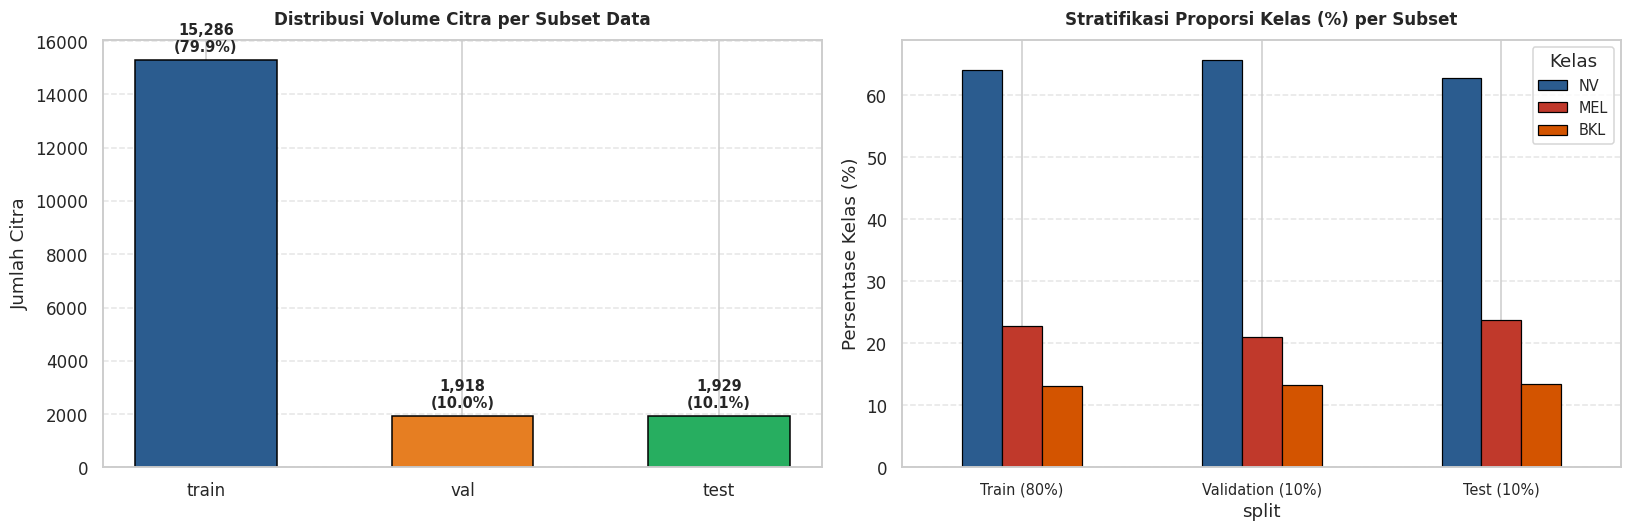


Sampling karakteristik resolusi fisik citra:


,Source Dataset,Sample Image ID,Resolusi (Px),Aspek Rasio,Kanal Warna,Format File
0,isic_2019_train,ISIC_0061409,1024 x 1024,1.00,RGB,JPEG
1,ham10000,ISIC_0029242,600 x 450,1.33,RGB,JPEG


In [55]:
split_crosstab = pd.crosstab(df_3kelas_final['split'], df_3kelas_final['harmonized_label'], margins=True)
split_prop = pd.crosstab(df_3kelas_final['split'], df_3kelas_final['harmonized_label'], normalize='index') * 100

print("Jumlah citra per kelas pada setiap subset:")
display(split_crosstab)

print("\nProporsi kelas (%) pada setiap subset:")
display(split_prop.round(2))

# Visualisasi Evaluasi Split
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Volume Citra
split_counts = df_3kelas_final['split'].value_counts()[['train', 'val', 'test']]
colors_split = ['#2b5c8f', '#e67e22', '#27ae60']
bars = axes[0].bar(split_counts.index, split_counts.values, color=colors_split, width=0.55, edgecolor='black', linewidth=1.0)
axes[0].set_title('Distribusi Volume Citra per Subset Data', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('Jumlah Citra')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for b in bars:
    yval = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2.0, yval + 200, f'{yval:,}\n({yval/len(df_3kelas_final)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# 2. Proporsi Kelas
split_prop_plot = split_prop.drop(index='All', errors='ignore').loc[['train', 'val', 'test']][['NV', 'MEL', 'BKL']]
split_prop_plot.plot(kind='bar', ax=axes[1], color=['#2b5c8f', '#c0392b', '#d35400'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Stratifikasi Proporsi Kelas (%) per Subset', fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel('Persentase Kelas (%)')
axes[1].set_xticklabels(['Train (80%)', 'Validation (10%)', 'Test (10%)'], rotation=0, fontsize=9.5)
axes[1].legend(title='Kelas', labels=['NV', 'MEL', 'BKL'], fontsize=9.5)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Karakteristik Fisik Citra
sources_unique = df_3kelas_final['source'].unique()
sample_specs = []
for src in sources_unique:
    row = df_3kelas_final[df_3kelas_final['source'] == src].iloc[0]
    try:
        with Image.open(row['filepath']) as img:
            sample_specs.append({
                'Source Dataset': src,
                'Sample Image ID': row['image_id'],
                'Resolusi (Px)': f"{img.size[0]} x {img.size[1]}",
                'Aspek Rasio': f"{img.size[0]/img.size[1]:.2f}",
                'Kanal Warna': img.mode,
                'Format File': img.format
            })
    except Exception as e:
        pass

print("\nSampling karakteristik resolusi fisik citra:")
display(pd.DataFrame(sample_specs))

## Langkah 12: Kesimpulan Data Preparation dan Kesiapan Modeling
Rangkuman hasil tahap Data Preparation versi hash-based dedup:
1. **Metode Deduplikasi:** Duplikat identik dibuang pakai MD5 Hash (exact match), duplikat mirip-tapi-gak-identik dibuang pakai pHash + Hamming Distance (near-duplicate). Beda dari versi awal yang cuma cocokin `image_id`.
2. **Total Citra Siap Latih:** Jumlah pasti bisa dilihat di output Langkah 7-10 di atas - kemungkinan beda dari versi ID-matching (22.051), soalnya cara deteksi duplikatnya beda pendekatan.
3. **Pencegahan Kebocoran Data:** Tetap 100% bebas kebocoran lesi pasien (overlap lesi antar-subset = 0), berkat StratifiedGroupKFold berbasis `lesion_id`, gak berubah dari versi sebelumnya.
4. **File CSV Tersimpan Rapi:** Semua file output ada di `/kaggle/working` (bukan folder input), siap dipakai DataLoader di notebook modeling selanjutnya.